# **Please note you need a GPU with at least 24GB memory to test this 3D turbulence generation**

# Imports

In [1]:
%env CUDA_VISIBLE_DEVICES = 0
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import sys
sys.path.append("../../../..")
from ConditionalDiffusionGeneration.src.guided_diffusion.unet import create_model
from ConditionalDiffusionGeneration.src.guided_diffusion.condition_methods import get_conditioning_method
from ConditionalDiffusionGeneration.src.guided_diffusion.measurements import get_noise, get_operator
from ConditionalDiffusionGeneration.src.guided_diffusion.gaussian_diffusion import create_sampler
from ConditionalNeuralField.cnf.inference_function import ReconstructFrame, decoder
from einops import rearrange

env: CUDA_VISIBLE_DEVICES=0


/ehome/zhao/.conda/envs/CoNFiLD/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
  dev = "cuda"
else:
  dev = "cpu"

device = torch.device(dev)
print(device)

cuda


# Conditioning Data Loader

# Load trained unconditional model

In [3]:
u_net_model = create_model(image_size= 64,
                           num_channels= 64,
                           num_res_blocks= 2,
                           num_heads=8,
                           # num_head_channels=32,
                           attention_resolutions="32,16,8,4,2",
                           channel_mult="1,1,2,2,4,4",
                           model_path='/ehome/zhao/nf/CoNFiLD/UnconditionalDiffusionTraining_and_Generation/output/logs_unet_large/ema_0.9999_100000.pt'
                        )

u_net_model.to(device)
u_net_model.eval()
print('loaded unet')

loaded unet


# Operator and Noise

In [4]:
operator =  get_operator(name='cartesian_sparse_measurement',
                        device=device,
                        ckpt_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt',
                        norm_record_path='/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/normalizer_params.pt',
                        simdata_path='/ehome/zhao/nf/CoNFiLD/Dataset/Cartesian_all3_small.npy',
                        simdata_idx=1999,
                        num_probed=10,
                        # ds_size=8,
                        )

Simulation data loaded, with shape (64, 64, 64, 3)


In [5]:
noiser = get_noise(sigma=0.0, name='gaussian')

## For masking in time

# Conditioning Method

In [ ]:
cond_method = get_conditioning_method(operator=operator, noiser=noiser, name='ps_adam', scale=1e-3)    # \lambda=1
measurement_cond_fn = partial(cond_method.conditioning)

# Sampler

In [7]:
sampler = create_sampler(sampler='ddpm',
                         steps=1000,
                         noise_schedule="cosine",
                         model_mean_type="epsilon",
                         model_var_type="fixed_large",
                         dynamic_threshold=False,
                         clip_denoised=True,
                         rescale_timesteps=False,
                         timestep_respacing="")

sample_fn = partial(sampler.p_sample_loop, model=u_net_model, measurement_cond_fn=measurement_cond_fn)

## Generate Samples

In [8]:
no_of_samples = 5
time_length = 64
latent_size = 256

In [ ]:
x_start = torch.randn(no_of_samples, 1, time_length, latent_size, device=device)
measurement_ref = operator.sparse_cartesian_measurement()
samples = [sample_fn(x_start=x_start[i:i+1], measurement=measurement_ref, record=False, save_root=None) for i in range(x_start.shape[0])]

Simulation data normed, with min -1.0, max 0.9781860113143921
Measurement shape: torch.Size([64, 10, 1])


  0%|          | 0/1000 [00:00<?, ?it/s]

 45%|████▌     | 453/1000 [00:40<00:45, 11.93it/s, distance=17.3]

In [ ]:
gen_latents = torch.cat(samples)
gen_latents = operator._unnorm(gen_latents)
gen_latents = gen_latents[:,0]

# Decoding latents to flow fields

In [ ]:
print(gen_latents.shape, gen_latents.device)

torch.Size([5, 64, 256]) cuda:0


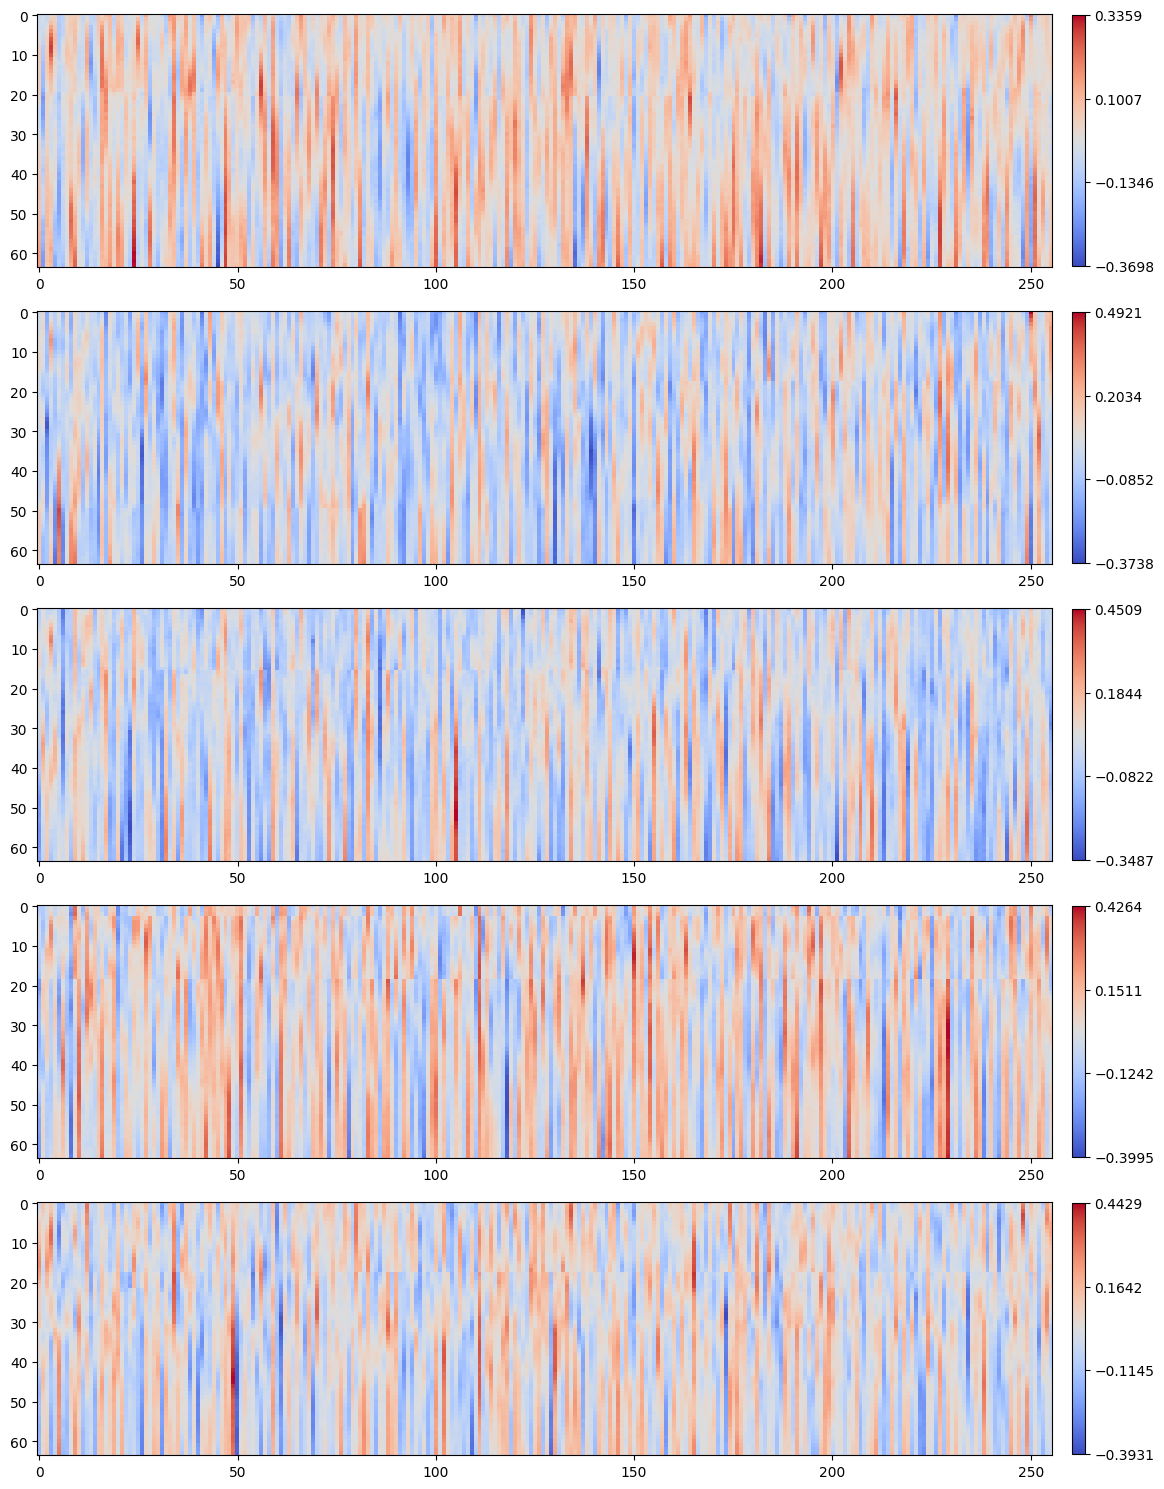

In [ ]:
fig, ax = plt.subplots(len(gen_latents), 1, figsize=(len(gen_latents)*4, len(gen_latents)*3))
ax = ax.flatten()
for i in range(gen_latents.shape[0]):
    cax = ax[i].imshow(gen_latents[i].detach().cpu().numpy(), cmap='coolwarm')
    cbar = fig.colorbar(cax, ax=ax[i], shrink=0.99, pad=0.01)
    ticks = np.linspace(gen_latents[i].min().item(), gen_latents[i].max().item(), 4)
    cbar.set_ticks(ticks)
plt.tight_layout()
plt.show()

In [ ]:
from ConditionalNeuralField.cnf.nf_networks import SIRENAutodecoder_mdf_film
nf = SIRENAutodecoder_mdf_film(omega_0=5,
                               in_coord_features=2,
                               in_latent_features=256,
                               out_features=3,
                               num_hidden_layers=5,
                               hidden_features=128)
ckpt = torch.load("/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/checkpoint_14996.pt")
nf.load_state_dict(ckpt['model_state_dict'])
nf.eval()
nf.to(device)
del ckpt
print('nf loaded')

nf loaded


In [ ]:
whole_coords = operator._gene_cartesian_coord()
print(whole_coords.shape)

torch.Size([64, 64, 2])


In [ ]:
whole_coords_in = whole_coords.unsqueeze(0).to(device)
gen_latents_in = rearrange(gen_latents, 'b t l -> (b t) 1 1 l' )
gen_latents_in = gen_latents_in.to(device)
nf_out_gene = nf(whole_coords_in, gen_latents_in)
nf_out_gene = operator._unnorm_cnf(nf_out_gene)
print(nf_out_gene.shape)

torch.Size([320, 64, 64, 3])


(5, 64, 64, 64, 3)
Simulation data normed, with min -1.0, max 0.9781860113143921
Measurement shape: torch.Size([64, 10, 2])
(64, 64, 64, 3)
(64, 10, 2)


TypeError: Invalid shape (64, 10, 2) for image data

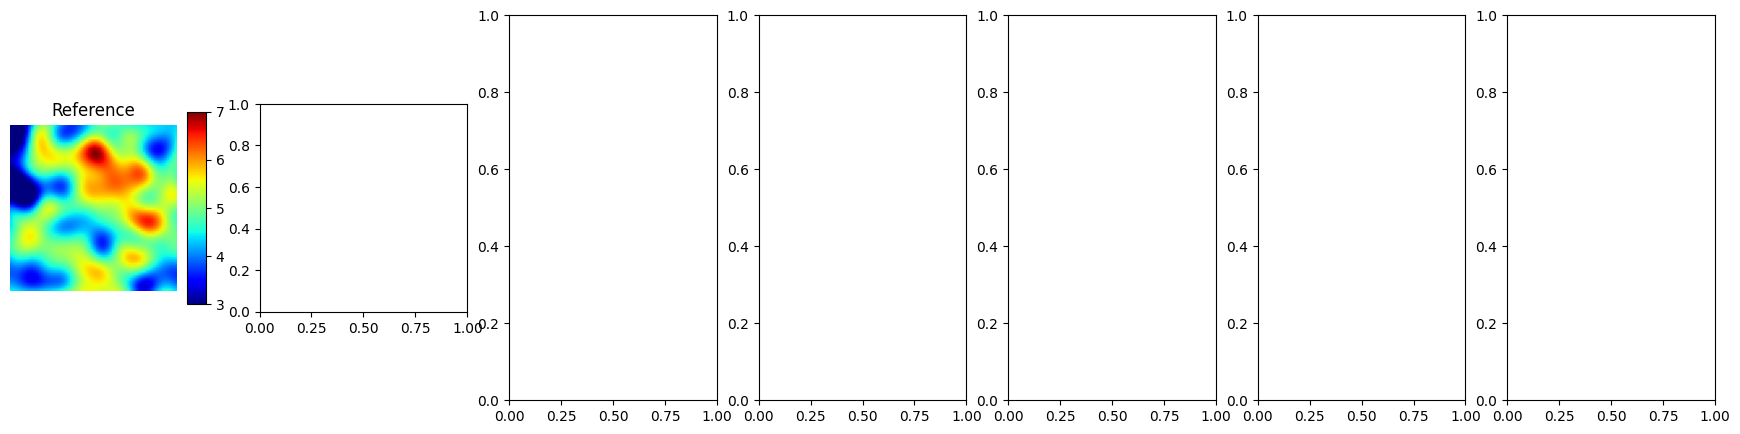

In [ ]:
all3 = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3).detach().cpu().numpy()
print(all3.shape)
# np.save(f'/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/pre_sat_perm{all3.shape}_condgene.npy', all3)
all3_ref = operator.simdata
downsample_k = operator.sparse_cartesian_measurement().squeeze().detach().cpu().numpy()
print(all3_ref.shape)
print(downsample_k.shape)
fig, ax = plt.subplots(1, 7, figsize=(22, 5))
for i in range(7):
    if i == 0:
        im1 = ax[i].imshow(all3_ref[0, :, :, -1], cmap='jet', vmin=3, vmax=7)
        fig.colorbar(im1, ax=ax[i], shrink=0.5, aspect=10)
        ax[i].set_title('Reference')
    elif i == 1:
        im3 = ax[i].imshow(downsample_k[ :, :], cmap='jet')
        fig.colorbar(im3, ax=ax[i], shrink=0.5, aspect=10)
        ax[i].set_title('Downsample')
    else:
        im2 = ax[i].imshow(all3[i-2, -1, :, :, -1], cmap='jet', vmin=3, vmax=7)
        fig.colorbar(im2, ax=ax[i], shrink=0.5, aspect=10)
        ax[i].set_title('Gene Sample %d' % (i-1))
    ax[i].axis('off')
    # measure_pts = operator.query_points
    # for y, x in measure_pts:
    #     ax[i].plot(x, y, marker='x', color='red', markersize=8)
plt.show()

(5, 64, 64, 64, 3)
(64, 64, 64, 3)


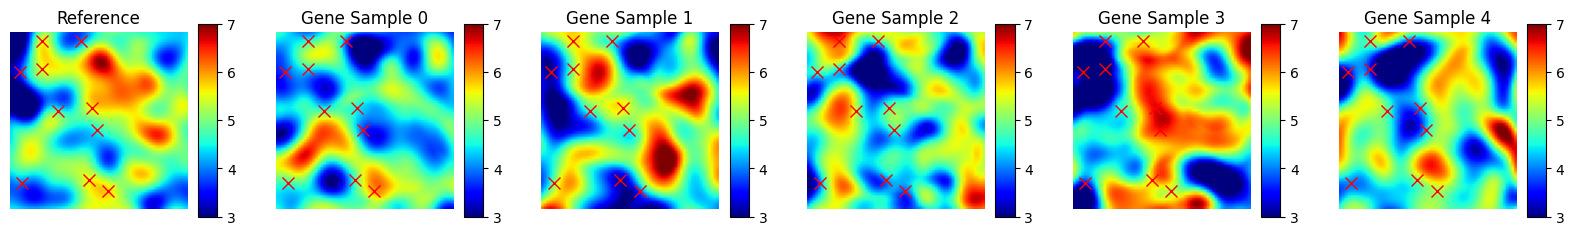

In [ ]:
all3 = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3).detach().cpu().numpy()
print(all3.shape)
# np.save(f'/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output_Cartesian_simple/all3_small/pre_sat_perm{all3.shape}_condgene.npy', all3)
all3_ref = operator.simdata
print(all3_ref.shape)
fig, ax = plt.subplots(1, 6, figsize=(20, 5))
for i in range(6):
    if i == 0:
        im1 = ax[i].imshow(all3_ref[0, :, :, -1], cmap='jet', vmin=3, vmax=7)
        fig.colorbar(im1, ax=ax[i], shrink=0.5, aspect=10)
        ax[i].set_title('Reference')
    else:
        im2 = ax[i].imshow(all3[i-1, -1, :, :, -1], cmap='jet', vmin=3, vmax=7)
        fig.colorbar(im2, ax=ax[i], shrink=0.5, aspect=10)
        ax[i].set_title('Gene Sample %d' % (i-1))
    ax[i].axis('off')
    measure_pts = operator.query_points
    for y, x in measure_pts:
        ax[i].plot(x, y, marker='x', color='red', markersize=8)
plt.show()

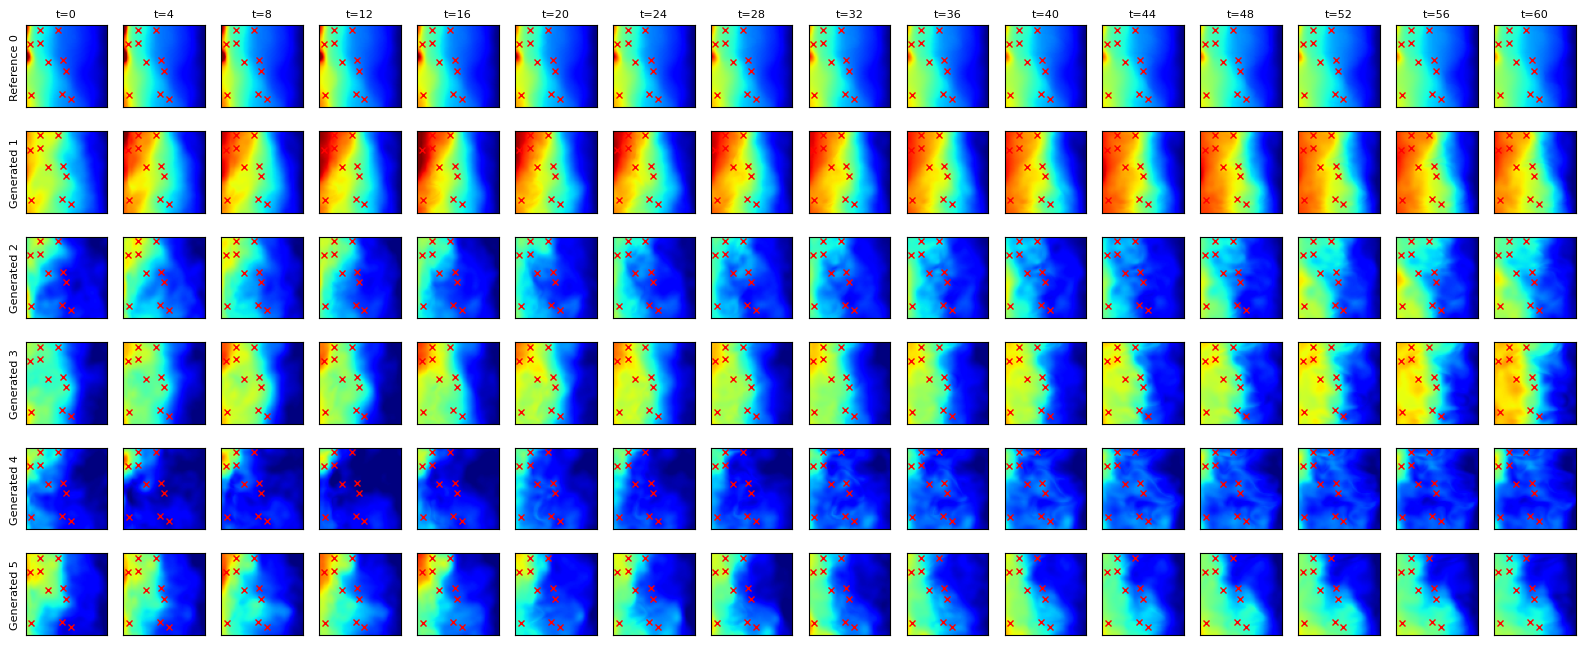

In [ ]:
fig, axs = plt.subplots(6, 16, figsize=(20, 8))
for row in range(6):
    for col in range(16):
        if row == 0:
            axs[row, col].imshow(operator.simdata[...,0][col*4], cmap='jet', vmin=12e6, vmax=16e6)
            measure_pts = operator.query_points
            for y, x in measure_pts:
                axs[row, col].plot(x, y, marker='x', color='red', markersize=5)
            
        else:
            axs[row, col].imshow(all3[row-1, col*4, :, :, 0], cmap='jet', vmin=12e6, vmax=16e6)
            for y, x in measure_pts:
                axs[row, col].plot(x, y, marker='x', color='red', markersize=5)
        axs[row, col].axis('on')
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        if row == 0:
            axs[row, col].set_title(f"t={col*4}", fontsize=8)
        if col == 0 and row != 0:
            axs[row, col].set_ylabel(f"Generated {row}", fontsize=8)
        if col == 0 and row == 0:
            axs[row, col].set_ylabel(f"Reference {row}", fontsize=8)

In [ ]:
nf_out_gene = nf_out_gene.reshape(no_of_samples, time_length, 64, 64, 3).detach().cpu().numpy()[..., 1]
print(nf_out_gene.shape)


(5, 64, 64, 64)


(64, 64, 64) (64, 64, 64)


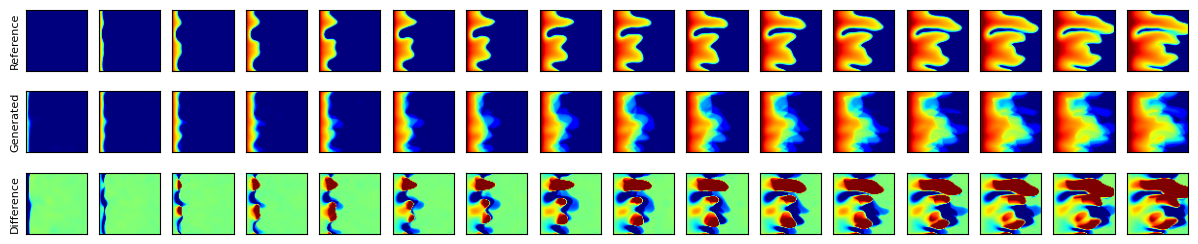

In [ ]:
avg_sat = np.mean(nf_out_gene, axis=0)
ref_sat = all3_ref[..., 1]
print(avg_sat.shape, ref_sat.shape)
fig, ax = plt.subplots(3, 16, figsize=(15, 3))
for i in range(16):
    ax[0, i].imshow(ref_sat[i*4], cmap='jet', vmin=0., vmax=0.5)
    ax[1, i].imshow(avg_sat[i*4], cmap='jet', vmin=0., vmax=0.5)
    ax[2, i].imshow(ref_sat[i*4] - avg_sat[i*4], cmap='jet', vmin=-0.1, vmax=0.1)
    ax[0, i].set_xticks([])
    ax[1, i].set_xticks([])
    ax[2, i].set_xticks([])
    ax[0, i].set_yticks([])
    ax[1, i].set_yticks([])
    ax[2, i].set_yticks([])
    if i == 0:
        ax[0, i].set_ylabel('Reference', fontsize=8)
        ax[1, i].set_ylabel('Generated', fontsize=8)
        ax[2, i].set_ylabel('Difference', fontsize=8)


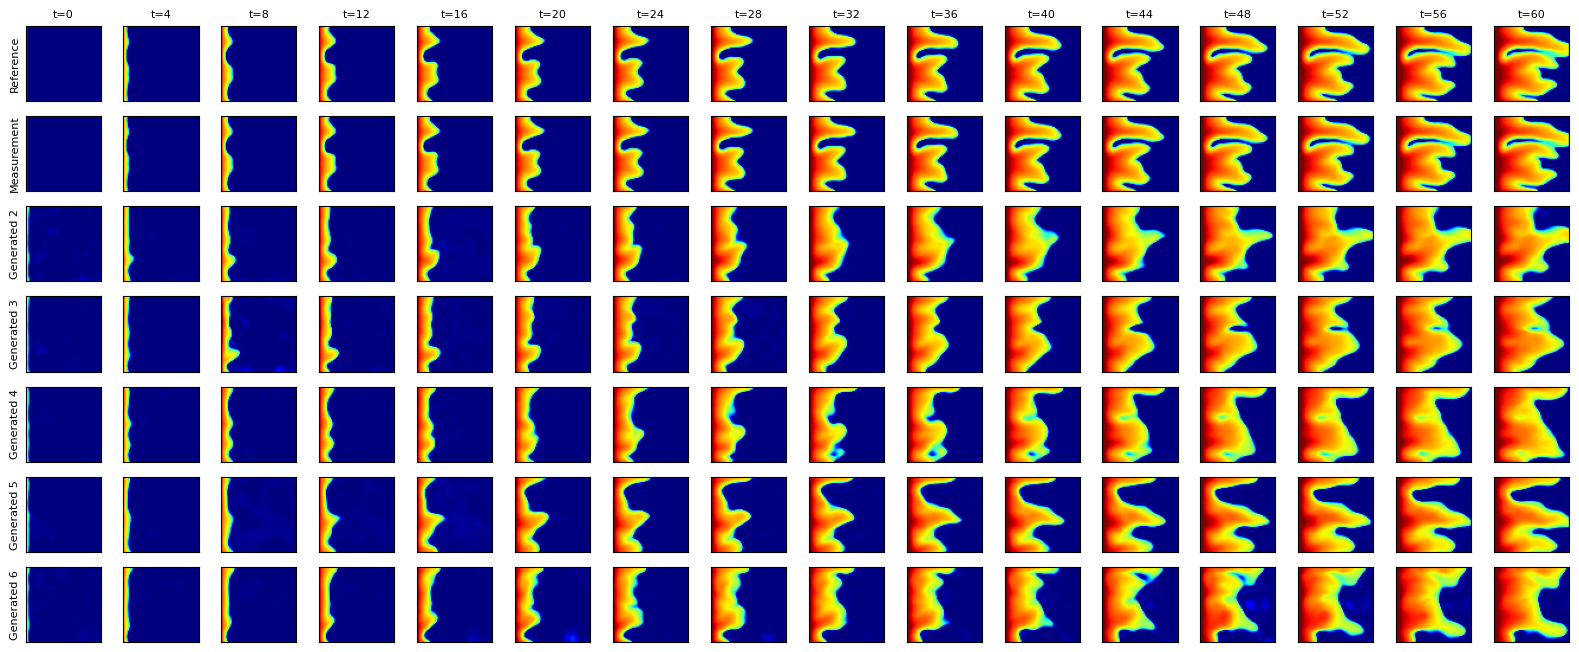

In [ ]:
fig, axs = plt.subplots(7, 16, figsize=(20, 8))
for row in range(7):
    for col in range(16):
        if row == 0:
            axs[row, col].imshow(operator.simdata[...,1][col*4], cmap='jet', vmin=0, vmax=0.5)

        if row == 1:
            axs[row, col].imshow(operator.simdata[...,1][col*4], cmap='jet', vmin=0, vmax=0.5)
        elif row > 1:
            axs[row, col].imshow(nf_out_gene[row-2, col*4], cmap='jet', vmin=0, vmax=0.5)

        axs[row, col].axis('on')
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        if row == 0:
            axs[row, col].set_title(f"t={col*4}", fontsize=8)
        if col == 0 and row > 1:
            axs[row, col].set_ylabel(f"Generated {row}", fontsize=8)
        if col == 0 and row == 0:
            axs[row, col].set_ylabel(f"Reference", fontsize=8)
        if col == 0 and row == 1:
            axs[row, col].set_ylabel(f"Measurement", fontsize=8)

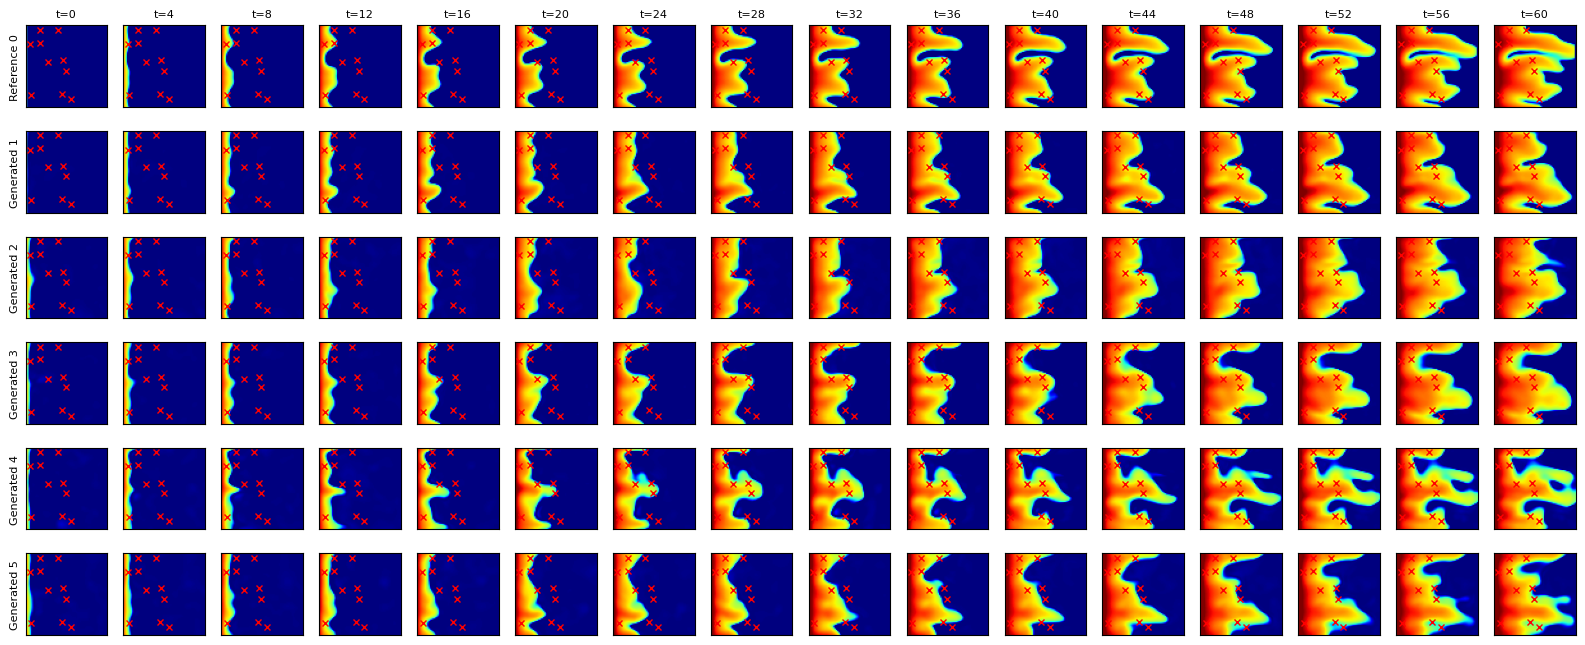

In [ ]:

fig, axs = plt.subplots(6, 16, figsize=(20, 8))
for row in range(6):
    for col in range(16):
        if row == 0:
            axs[row, col].imshow(operator.simdata[...,1][col*4], cmap='jet', vmin=0, vmax=0.5)
            measure_pts = operator.query_points
            for y, x in measure_pts:
                axs[row, col].plot(x, y, marker='x', color='red', markersize=5)
            
        else:
            axs[row, col].imshow(nf_out_gene[row-1, col*4], cmap='jet', vmin=0, vmax=0.5)
            for y, x in measure_pts:
                axs[row, col].plot(x, y, marker='x', color='red', markersize=5)
        axs[row, col].axis('on')
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        if row == 0:
            axs[row, col].set_title(f"t={col*4}", fontsize=8)
        if col == 0 and row != 0:
            axs[row, col].set_ylabel(f"Generated {row}", fontsize=8)
        if col == 0 and row == 0:
            axs[row, col].set_ylabel(f"Reference {row}", fontsize=8)


In [ ]:
reference_sat = operator.sparse_cartesian_measurement()
# reference_sat = operator._unnorm_cnf(reference_sat)
norm_records = operator.out_normalizer.params
print(norm_records)
max_sat, min_sat = norm_records[0][0][1], norm_records[1][0][1]
reference_sat = (reference_sat + 1) / 2 * (max_sat - min_sat) + min_sat
print(f"reference shape: {reference_sat.shape}, generated shape: {nf_out_gene.shape}")

Simulation data normed, with min -1.0, max 0.9781860113143921
Measurement shape: torch.Size([64, 10, 2])
(tensor([[2.7590e+07, 6.2633e-01, 9.1085e+00]]), tensor([[ 1.2000e+07,  0.0000e+00, -2.2022e-01]]))
reference shape: torch.Size([1, 64, 10, 2]), generated shape: (5, 64, 64, 64)


In [ ]:
measure_pts = operator.query_points
print(measure_pts)

[(14, 3), (35, 31), (28, 17), (13, 11), (54, 4), (3, 11), (27, 29), (3, 25), (53, 28), (57, 35)]


In [ ]:
gene_measurements  = np.array([[[nf_out_gene[s, t, i, j] for (i, j) in measure_pts] for t in range(nf_out_gene.shape[1])] for s in range(nf_out_gene.shape[0])])
print(f"generated measurements shape: {gene_measurements.shape}")


generated measurements shape: (5, 64, 10)


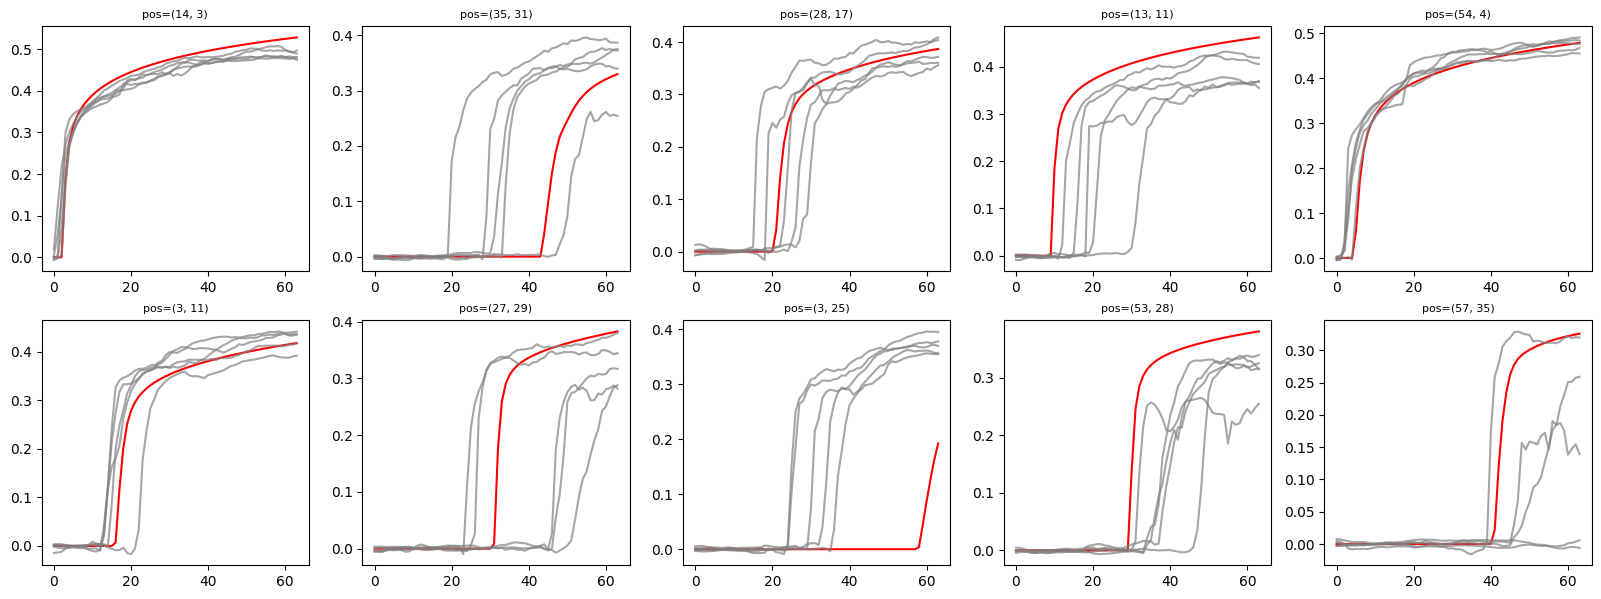

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20, 7))
for row in range(2):
    for col in range(5):
        if row == 0:
            axs[row, col].plot(reference_sat[0, :, col, 1].cpu().numpy(), color='red')
            axs[row, col].set_title(f"pos={measure_pts[row+col]}", fontsize=8)
            for i in range(5):
                axs[row, col].plot(gene_measurements[i, :, col], color='grey', alpha=0.7, ls='-')
        elif row == 1:
            axs[row, col].plot(reference_sat[0, :, col+5, 1].cpu().numpy(), color='red')
            axs[row, col].set_title(f"pos={measure_pts[col+5]}", fontsize=8)
            for i in range(5):
                axs[row, col].plot(gene_measurements[i, :, col+5], color='grey', alpha=0.7, ls='-')

plt.show()

## Use Latent Mapping & Neural Field to Get Uncertain Permeabilities

In [ ]:
print("Diffusion generated latents:")
print(gen_latents.shape, gen_latents.device)

Diffusion generated latents:
torch.Size([5, 64, 256]) cuda:0


In [ ]:
from ConditionalNeuralField.scripts.train_latent_mapping import LatentMapping
import sys
sys.path.append("/ehome/zhao/nf/CoNFiLD")

my_cnn_out_dim = 256
my_mlp_out_dim = 256
my_hidden_dims = [512, 256]

solution_ckpt_path = "/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output/saturation2/checkpoint_4999.pt"
param_ckpt_path = "/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output/permeability/checkpoint_4999.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_save_path = "/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output/LatentMapping"
    
latent_mapping = LatentMapping(
    solution_ckpt_path=solution_ckpt_path,
    param_ckpt_path=param_ckpt_path,
    device=device,
    train_save_path=train_save_path,
)

latent_param = latent_mapping.inference(cnn_out_dim=my_cnn_out_dim, mlp_out_dim=my_mlp_out_dim, mlp_hidden_dims=my_mlp_out_dim, input_data=gen_latents)
print(f"Latent mapping output shape: {latent_param.shape}")

TypeError: LatentMapping.__init__() got an unexpected keyword argument 'solution_ckpt_path'

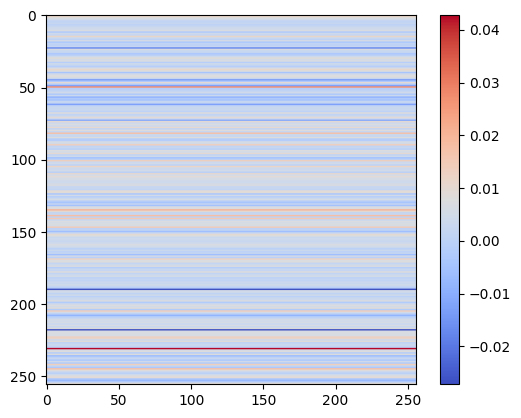

In [ ]:
wide_vec = np.repeat(latent_param[0].cpu().numpy().reshape(-1, 1), 256, axis=1)
plt.imshow(wide_vec, cmap='coolwarm')
plt.colorbar()

torch.Size([49999, 256])


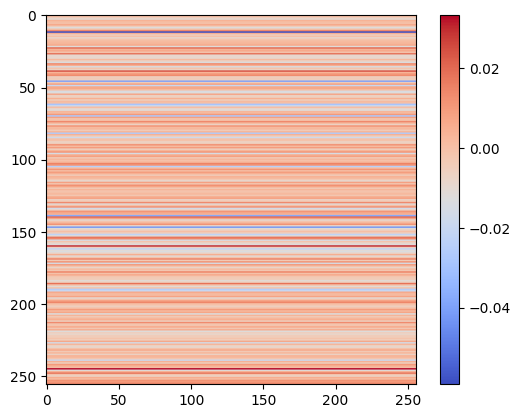

In [ ]:
kkk = torch.load(param_ckpt_path)
print(kkk["hidden_states"]["latents"].shape)
k = kkk["hidden_states"]["latents"]
wide_vec = np.repeat(k[10].cpu().numpy().reshape(-1, 1), 256, axis=1)
plt.imshow(wide_vec, cmap='coolwarm')
plt.colorbar()

sat latent shape: torch.Size([320000, 64])


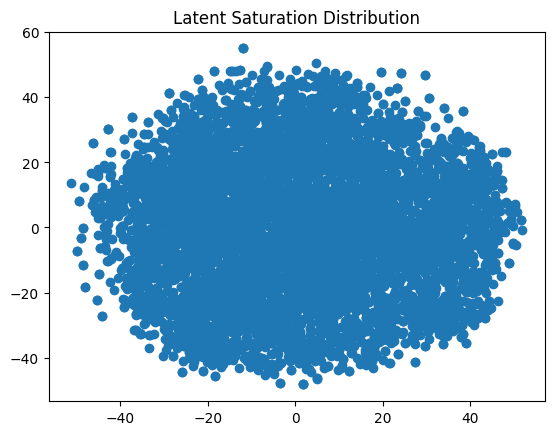

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sat_latent_ckpt = torch.load(solution_ckpt_path)
sat_latent = ckpt["hidden_states"]["latents"][:64*5000]
print(f"sat latent shape: {sat_latent.shape}")
view_sat = sat_latent.cpu().numpy()
latent_k = view_sat.reshape(5000, 64*64)

tsne = TSNE(n_components=2).fit_transform(latent_k)
plt.scatter(tsne[:, 0], tsne[:, 1])
plt.title("Latent Saturation Distribution")
plt.show()

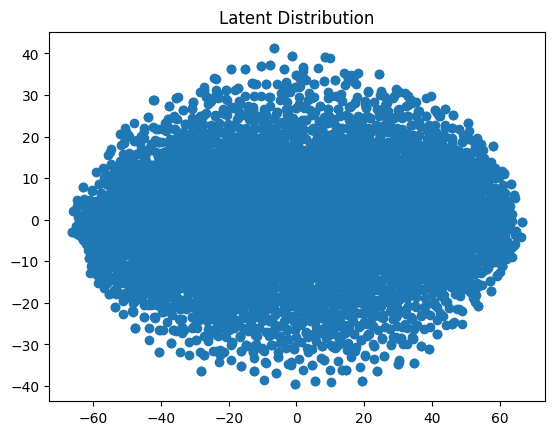

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

view_k = k[:5000].cpu().numpy()
latent_k = view_k.reshape(len(view_k), -1)

tsne = TSNE(n_components=2).fit_transform(latent_k)
plt.scatter(tsne[:, 0], tsne[:, 1])
plt.title("Latent Distribution")
plt.show()

In [ ]:
permeability_nf = SIRENAutodecoder_mdf_film(2, 256, 1, 6, 256)
permeability_nf.load_state_dict(torch.load(param_ckpt_path)['model_state_dict'])
permeability_nf.eval()
permeability_nf.to(device)
print('permeability nf loaded')

permeability nf loaded


In [ ]:
latent_param_in = rearrange(latent_param, 'b l -> b 1 1 l' )
permeability_nf_out = permeability_nf(whole_coords_in, latent_param_in.to(device))
print(f"Permeability nf output shape: {permeability_nf_out.shape}")

Permeability nf output shape: torch.Size([5, 64, 64, 1])


In [ ]:
permeability_nf_out = permeability_nf_out.detach().cpu()
perm_normalizer = torch.load("/ehome/zhao/nf/CoNFiLD/ConditionalNeuralField/output/permeability/normalizer_params.pt")
_, perm_records = perm_normalizer["x_normalizer_params"], perm_normalizer["y_normalizer_params"]
perm_max, perm_min = perm_records[0], perm_records[1]
permeability_nf_out = (permeability_nf_out + 1) * (perm_max - perm_min) / 2 + perm_min
uncertain_perm = permeability_nf_out[..., 0].numpy()
print(f"Uncertain permeability shape: {uncertain_perm.shape}, max: {uncertain_perm.max()}, min: {uncertain_perm.min()}")

Uncertain permeability shape: (5, 64, 64), max: 6.673673152923584, min: 2.3704848289489746


In [ ]:
reference_perm = operator.sparse_cartesian_measurement()["reference_param"]
print(f"Reference permeability shape: {reference_perm.shape}, max: {reference_perm.max()}, min: {reference_perm.min()}")

Reference permeability shape: (64, 64), max: 6.625586032867432, min: 2.329071044921875


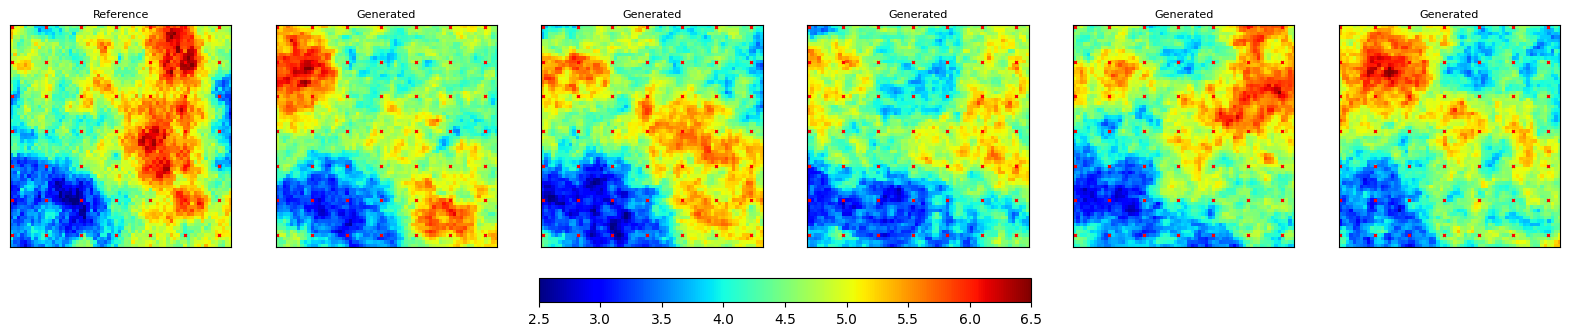

In [ ]:
fig, axs = plt.subplots(1, 6, figsize=(20, 4))
for col in range(6):
    if col == 0:
        im = axs[col].imshow(reference_perm, cmap='jet', vmin=2.5, vmax=6.5)
        axs[col].set_title(f"Reference", fontsize=8)
    else:
        im = axs[col].imshow(uncertain_perm[col-1], cmap='jet', vmin=2.5, vmax=6.5)
        axs[col].set_title(f"Generated", fontsize=8)
    
    measure_pts = operator.query_points
    for y, x in measure_pts:
        axs[col].plot(x, y, marker='x', color='red', markersize=2)
    
    axs[col].axis('on')
    axs[col].set_xticks([])
    axs[col].set_yticks([])

# Add a colorbar
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.08, pad=0.1)

plt.show()

In [ ]:
measure_pts = operator.query_points
print(measure_pts)
reference_measurements = np.array([reference_perm[i, j] for (i, j) in measure_pts])
print(f"reference measurements shape: {reference_measurements.shape}")
gene_measurements  = np.array([[uncertain_perm[s, i, j] for (i, j) in measure_pts] for s in range(uncertain_perm.shape[0])])
print(f"generated measurements shape: {gene_measurements.shape}")

[(0, 0), (10, 0), (20, 0), (30, 0), (40, 0), (50, 0), (60, 0), (0, 10), (10, 10), (20, 10), (30, 10), (40, 10), (50, 10), (60, 10), (0, 20), (10, 20), (20, 20), (30, 20), (40, 20), (50, 20), (60, 20), (0, 30), (10, 30), (20, 30), (30, 30), (40, 30), (50, 30), (60, 30), (0, 40), (10, 40), (20, 40), (30, 40), (40, 40), (50, 40), (60, 40), (0, 50), (10, 50), (20, 50), (30, 50), (40, 50), (50, 50), (60, 50), (0, 60), (10, 60), (20, 60), (30, 60), (40, 60), (50, 60), (60, 60)]
reference measurements shape: (49,)
generated measurements shape: (5, 49)


In [ ]:
mean_value = np.mean(gene_measurements, axis=0)
joined_array = np.concatenate((reference_measurements[None,...], mean_value[None,...], gene_measurements), axis=0)

print(joined_array.shape)

(7, 49)


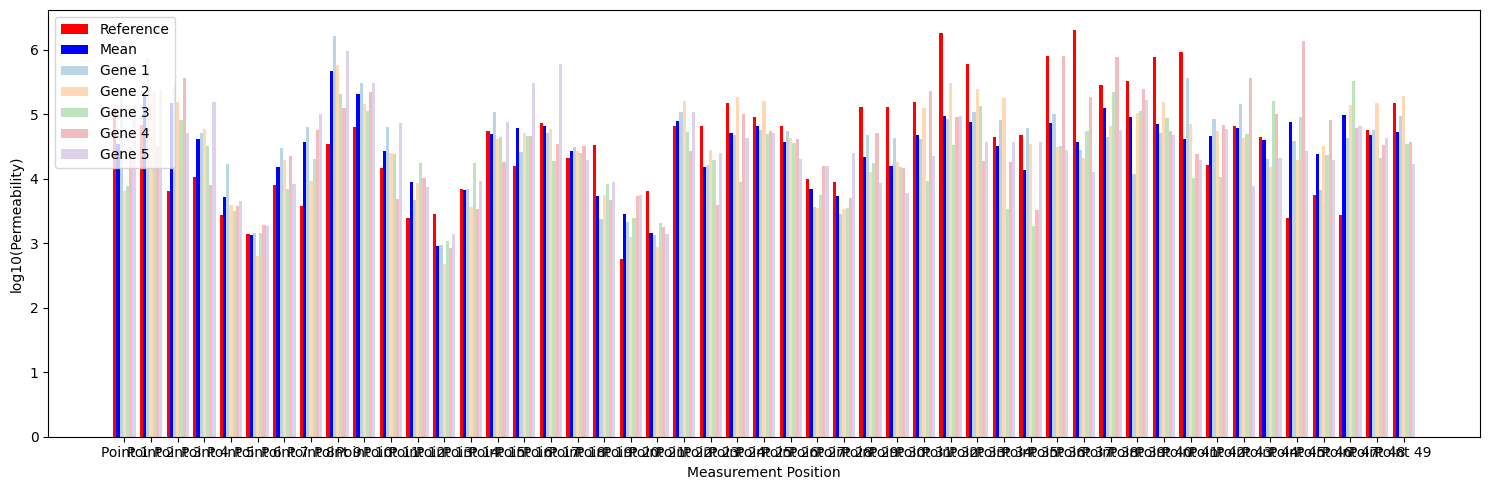

In [ ]:
n_bars, n_groups = joined_array.shape  # 6, 10
x = np.arange(n_groups)  # x 轴位置：10组

bar_width = 0.12
offsets = np.linspace(-bar_width*3, bar_width*3, n_bars)

fig, ax = plt.subplots(figsize=(15, 5))

for i in range(n_bars):
    if i == 0:
        ax.bar(x + offsets[i], joined_array[i], width=bar_width, label='Reference', color='red')
    elif i == 1:
        ax.bar(x + offsets[i], joined_array[i], width=bar_width, label='Mean', color='blue')
    else:
        ax.bar(x + offsets[i], joined_array[i], width=bar_width, label=f'Gene {i-1}', alpha=0.3)

ax.set_xlabel("Measurement Position")
ax.set_ylabel("log10(Permeability)")
ax.set_xticks(x)
ax.set_xticklabels([f'Point {i+1}' for i in range(n_groups)])
ax.legend()
plt.tight_layout()
plt.show()